## 00.a Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import EllipseModel, ransac
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture

# Load Mnist dataset
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

## 00.b Import dataset

In [3]:
# Load the dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Display the shape of the dataset
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


## 01.a Different smoothness of images with **Gaussian Blur**

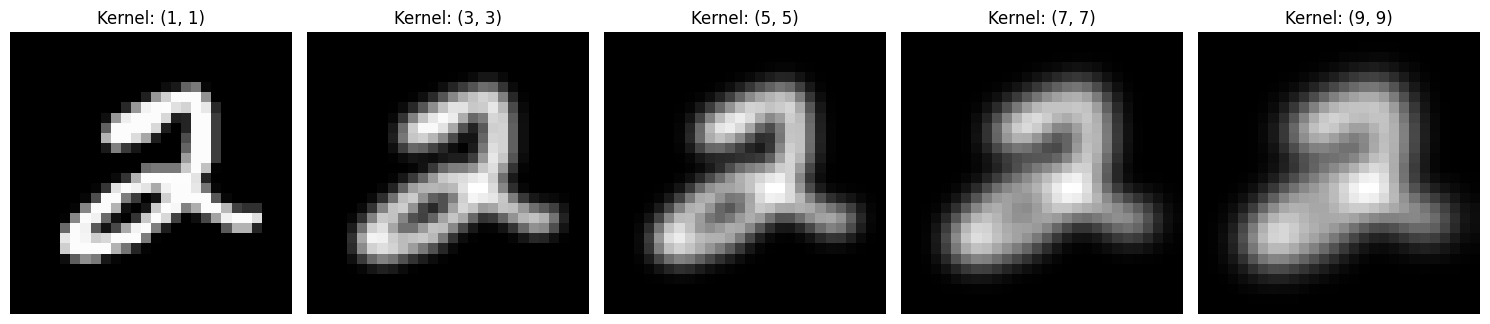

In [7]:
# Load the image in grayscale (recommended for shape detection)
two_image = train_images[train_labels == 2][0]

# Define the kernel sizes for different levels of blur
kernel_sizes = [(1, 1), (3, 3), (5, 5), (7, 7), (9, 9)]
blurred_images = []

# Apply Gaussian blur with each kernel size
for ksize in kernel_sizes:
    if ksize == (1, 1):
        blurred = two_image.copy()  # No blur
    else:
        blurred = cv2.GaussianBlur(two_image, ksize, 0)
    blurred_images.append((ksize, blurred))

# Display the results
plt.figure(figsize=(15, 5))
for idx, (ksize, blurred) in enumerate(blurred_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(blurred, cmap='gray')
    plt.title(f'Kernel: {ksize}')
    plt.axis('off')

plt.tight_layout()
plt.show()


## 01.b Different smoothness of images with **Median Blur**

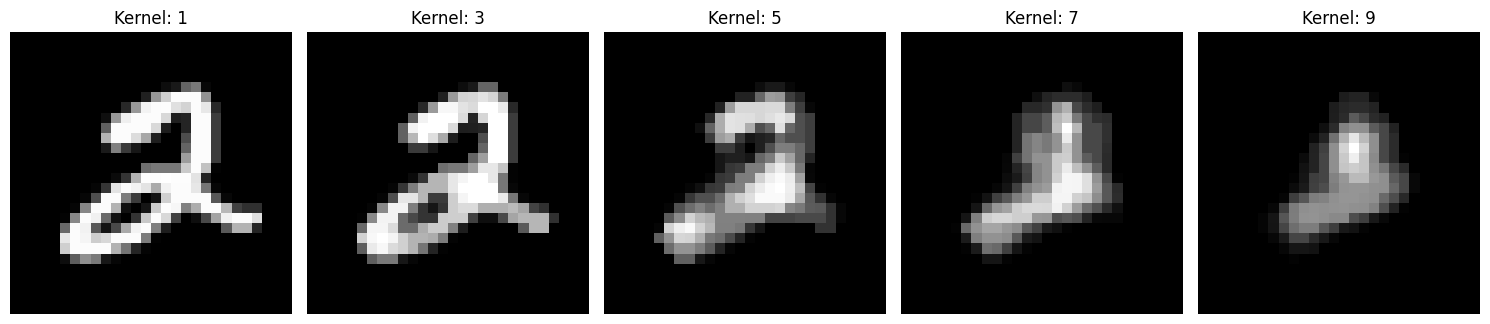

In [10]:
# Load the image in grayscale (recommended for shape detection)
two_image = train_images[train_labels == 2][0]

# Define the kernel sizes for different levels of blur for median blur
kernel_sizes = [1, 3, 5, 7, 9]
blurred_images = []

# Apply Gaussian blur with each kernel size
for ksize in kernel_sizes:
    if ksize == (1, 1):
        blurred = two_image.copy()  # No blur
    else:
        blurred = cv2.medianBlur(two_image, ksize)
    blurred_images.append((ksize, blurred))

# Display the results
plt.figure(figsize=(15, 5))
for idx, (ksize, blurred) in enumerate(blurred_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(blurred, cmap='gray')
    plt.title(f'Kernel: {ksize}')
    plt.axis('off')

plt.tight_layout()
plt.show()


## 01.c Different smoothness of images with **Box Blur**

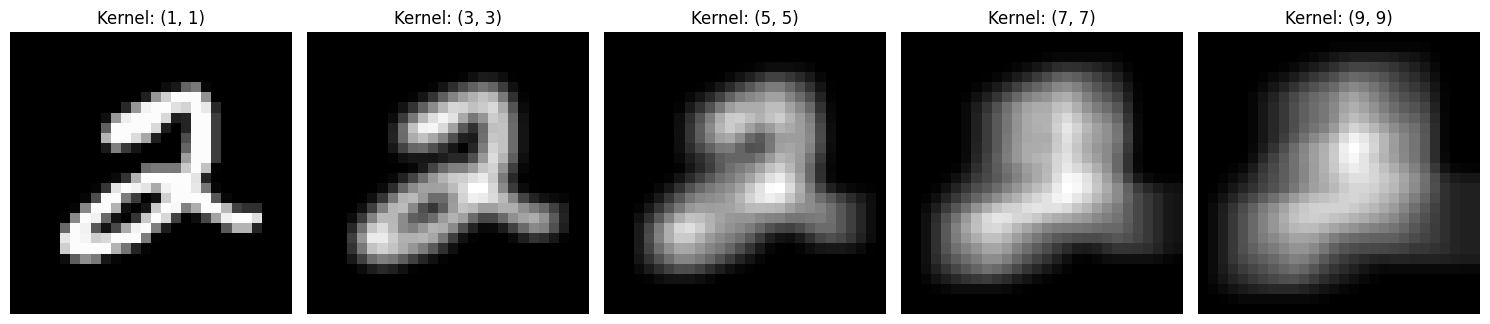

In [11]:
# Load the image in grayscale (recommended for shape detection)
two_image = train_images[train_labels == 2][0]

# Define the kernel sizes for different levels of blur
kernel_sizes = [(1, 1), (3, 3), (5, 5), (7, 7), (9, 9)]
blurred_images = []

# Apply Gaussian blur with each kernel size
for ksize in kernel_sizes:
    if ksize == (1, 1):
        blurred = two_image.copy()  # No blur
    else:
        blurred = cv2.blur(two_image, ksize)
    blurred_images.append((ksize, blurred))

# Display the results
plt.figure(figsize=(15, 5))
for idx, (ksize, blurred) in enumerate(blurred_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(blurred, cmap='gray')
    plt.title(f'Kernel: {ksize}')
    plt.axis('off')

plt.tight_layout()
plt.show()


## 01.c Different smoothness of images with **Bilateral filtering**

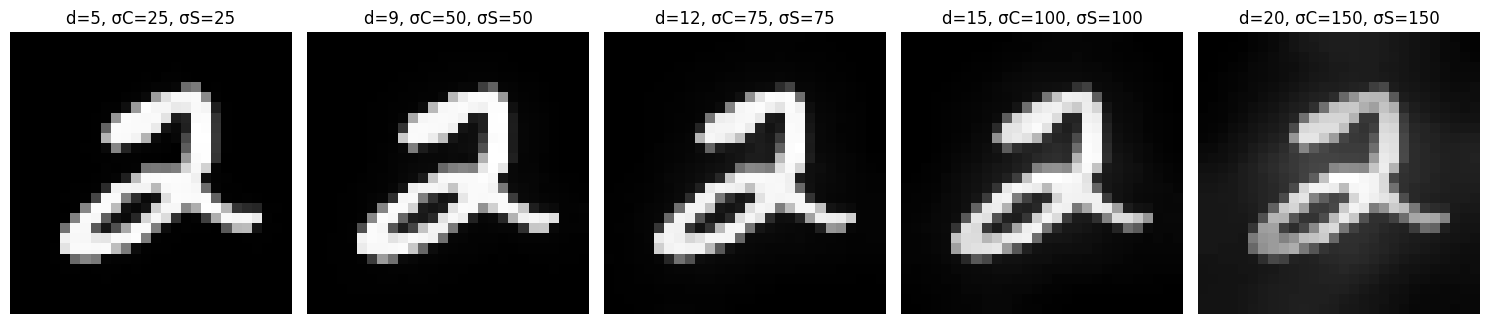

In [8]:
# Load the image in grayscale (recommended for shape detection)
two_image = train_images[train_labels == 2][0]

# Parameters for bilateral filtering
# (diameter, sigmaColor, sigmaSpace)
params = [
    (5, 25, 25),
    (9, 50, 50),
    (12, 75, 75),
    (15, 100, 100),
    (20, 150, 150)
]

filtered_images = []

# Apply bilateral filter with different parameter sets
for d, sigmaColor, sigmaSpace in params:
    filtered = cv2.bilateralFilter(two_image, d, sigmaColor, sigmaSpace)
    filtered_images.append(((d, sigmaColor, sigmaSpace), filtered))

# Display the results
plt.figure(figsize=(15, 5))
for idx, ((d, sigmaColor, sigmaSpace), filtered) in enumerate(filtered_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(filtered, cmap='gray')
    plt.title(f'd={d}, σC={sigmaColor}, σS={sigmaSpace}')
    plt.axis('off')

plt.tight_layout()
plt.show()


## 01.d Different smoothness of images with **Anisotropic Diffusion / Perona-Malik**

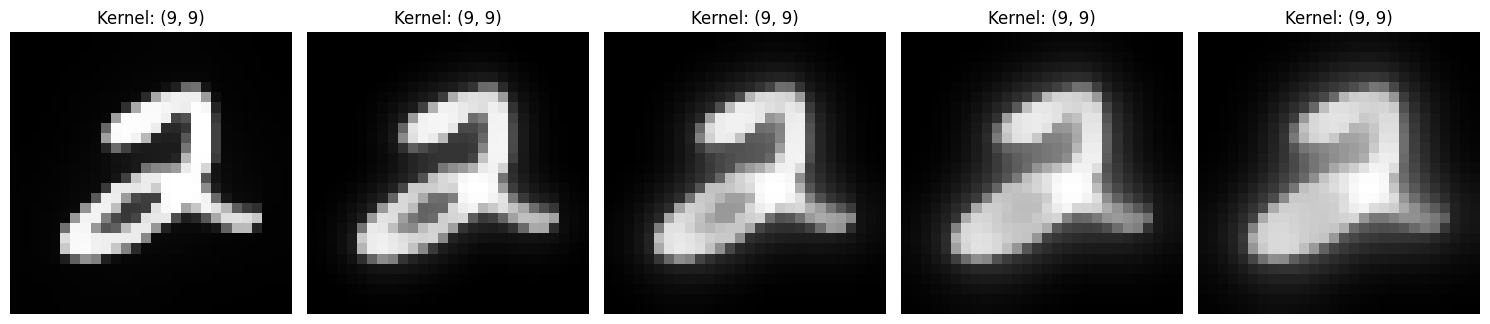

In [9]:
from skimage.restoration import denoise_tv_chambolle

# Load the image in grayscale (recommended for shape detection)
two_image = train_images[train_labels == 2][0]

# Define the kernel sizes for different levels of blur
weights = [0.1, 0.2, 0.3, 0.4, 0.5]

blurred_images = []

# Apply Gaussian blur with each kernel size
for weight in weights:
    blurred = denoise_tv_chambolle(two_image, weight=weight)
    blurred_images.append((ksize, blurred))

# Display the results
plt.figure(figsize=(15, 5))
for idx, (ksize, blurred) in enumerate(blurred_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(blurred, cmap='gray')
    plt.title(f'Kernel: {ksize}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Load the image in grayscale (recommended for shape detection)
two_image = train_images[train_labels == 2][0]
contours, _ = cv2.findContours(two_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cnt = contours[0].squeeze()

## 02.a Smoothing the edges in the images with **Gaussian Smoothing on Contour Points**

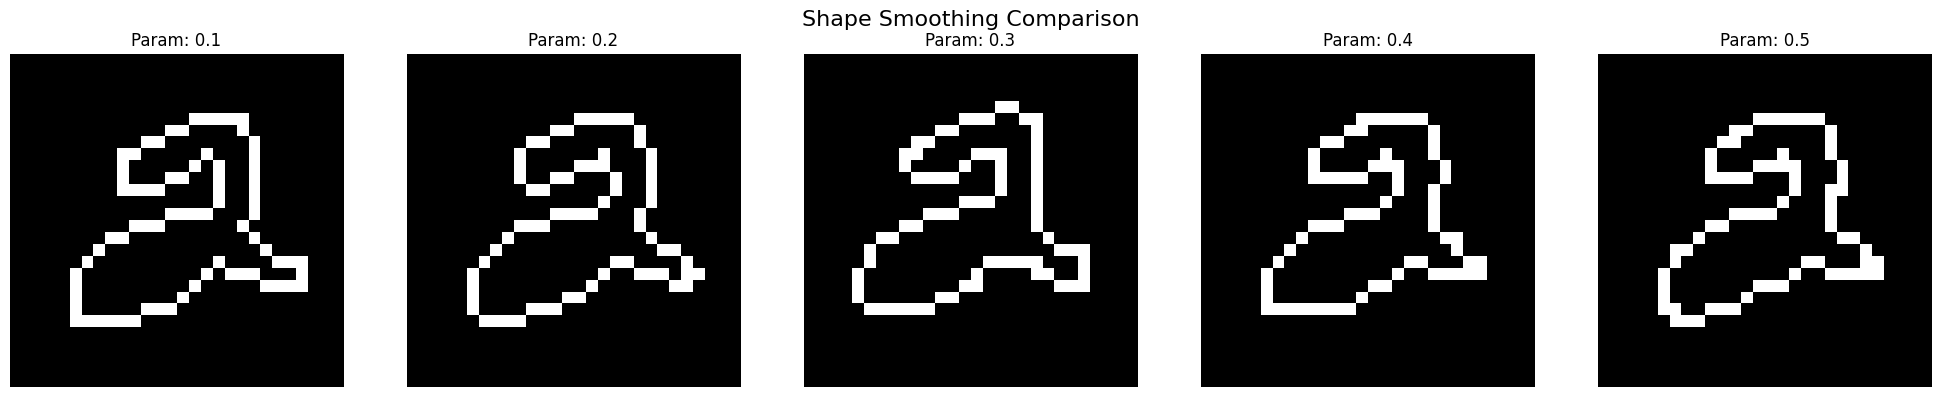

In [ ]:
from scipy.ndimage import gaussian_filter1d

# Define the kernel sizes for different levels of blur
sigmas = [0.1, 0.2, 0.3, 0.4, 0.5]

blurred_images = []

# Apply Gaussian blur with each kernel size
for sigma in sigmas:
    x_smooth = gaussian_filter1d(cnt[:, 0], sigma=sigma)
    y_smooth = gaussian_filter1d(cnt[:, 1], sigma=sigma)
    smoothed_contour = np.stack((x_smooth, y_smooth), axis=1).astype(np.int32)

    canvas = np.zeros_like(two_image)
    cv2.drawContours(canvas, [smoothed_contour], -1, 255, 1)

    blurred_images.append((sigma, canvas))


plt.figure(figsize=(20, 4))  # Wide layout: 5 images in a row

for idx, (param, img) in enumerate(blurred_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Param: {param}', fontsize=12)
    plt.axis('off')

plt.suptitle("Shape Smoothing Comparison", fontsize=16)
plt.tight_layout()
plt.show()

## 02.b Smoothing the edges in the images with **Morphological Smoothing**

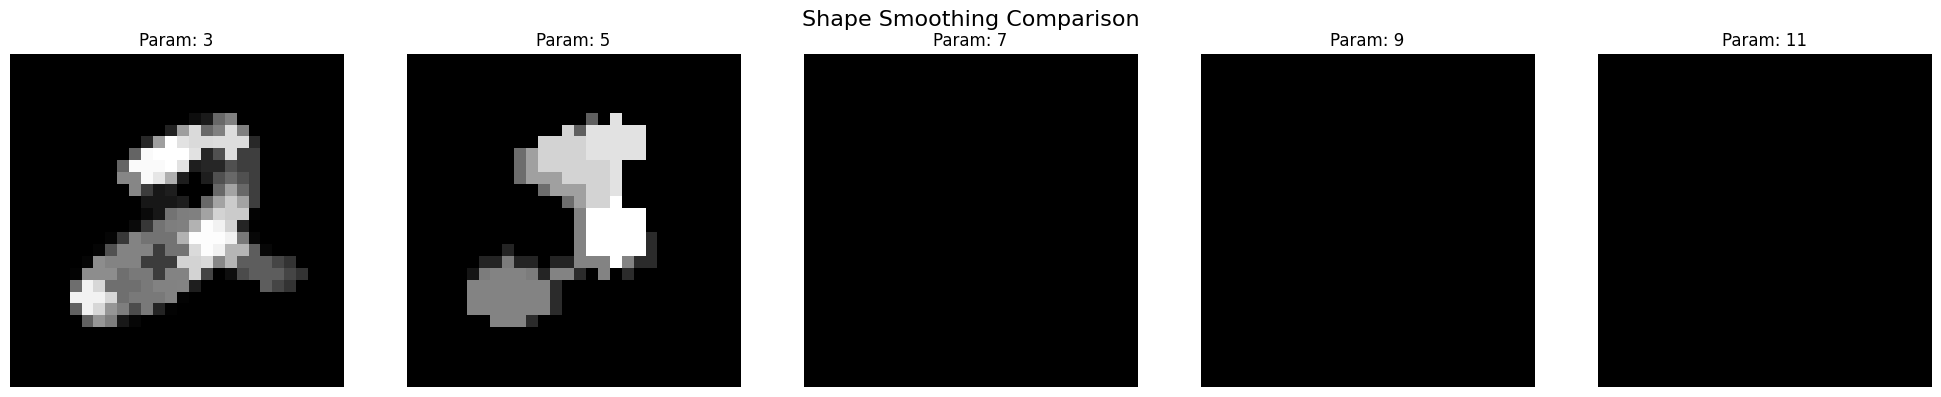

In [17]:
ksizes = [3, 5, 7, 9, 11]
blurred_images = []

for ksize in ksizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    opened = cv2.morphologyEx(two_image, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    blurred_images.append((ksize, closed))


plt.figure(figsize=(20, 4))  # Wide layout: 5 images in a row

for idx, (param, img) in enumerate(blurred_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Param: {param}', fontsize=12)
    plt.axis('off')

plt.suptitle("Shape Smoothing Comparison", fontsize=16)
plt.tight_layout()
plt.show()

## 02.c Smoothing the edges in the images with **Active Contours (Snakes)**

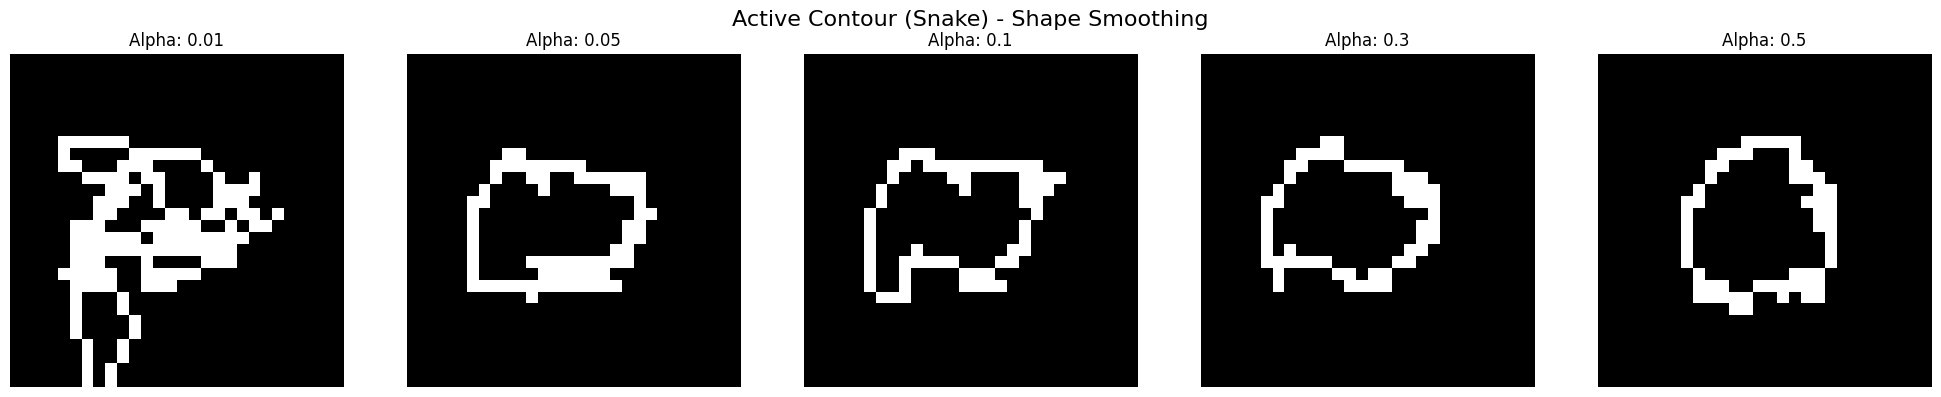

In [22]:
from skimage.segmentation import active_contour

alphas = [0.01, 0.05, 0.1, 0.3, 0.5]  # Alpha: elasticity (higher = stiffer)
blurred_images = []

# Initial snake: circle around center of MNIST image (28x28)
s = np.linspace(0, 2 * np.pi, 100)
x = 14 + 8 * np.cos(s)  # center x = 14, radius = 8
y = 14 + 8 * np.sin(s)  # center y = 14, radius = 8
init = np.array([y, x]).T

# Iterate over alpha values
for alpha in alphas:
    # Apply active contour (snake) method
    snake = active_contour(two_image.astype(float), init, alpha=alpha, beta=10, gamma=0.001)

    # Create canvas and draw snake
    canvas = np.zeros_like(two_image)
    snake_int = np.round(snake).astype(np.int32)
    cv2.drawContours(canvas, [snake_int], -1, 255, 1)  # Draw contour in white

    blurred_images.append((alpha, canvas))

# Plotting the results in a grid
plt.figure(figsize=(20, 4))  # Wide layout: 5 images in a row

for idx, (param, img) in enumerate(blurred_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Alpha: {param}', fontsize=12)
    plt.axis('off')

plt.suptitle("Active Contour (Snake) - Shape Smoothing", fontsize=16)
plt.tight_layout()
plt.show()

## 02.d Smoothing the edges in the images with **Level Set Smoothing (MorphGAC)**

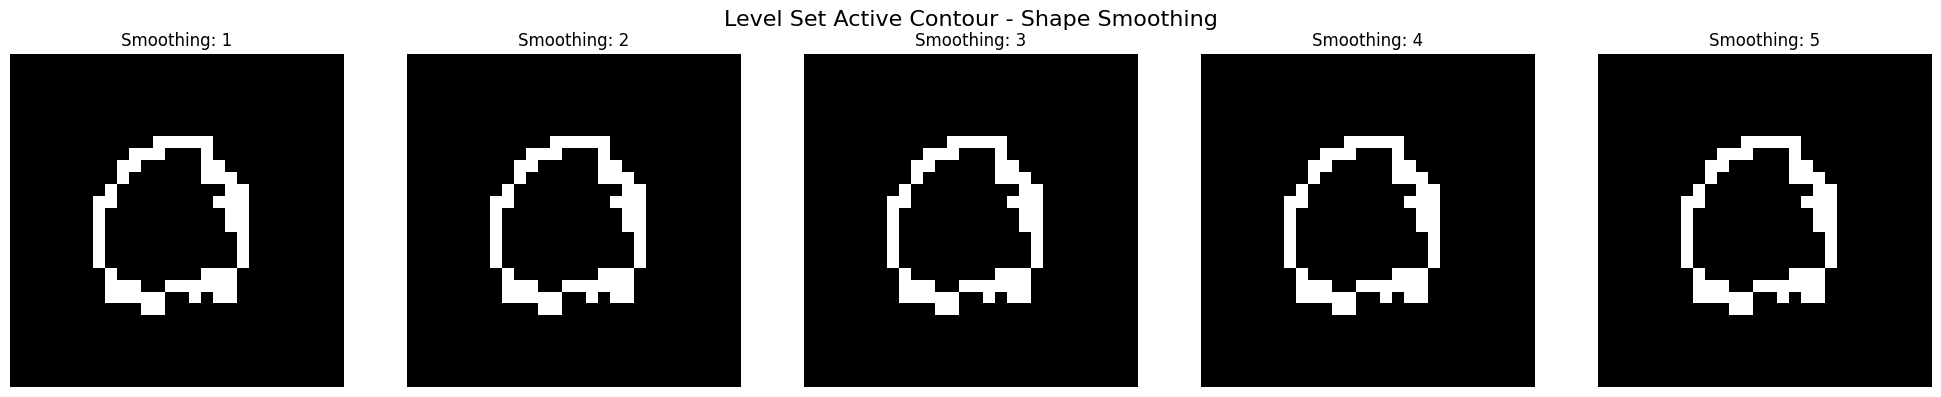

In [28]:
from skimage.segmentation import morphological_geodesic_active_contour, inverse_gaussian_gradient

smoothing_levels = [1, 2, 3, 4, 5]  # Smoothing values for the level-set method
blurred_images = []

# Prepare the gradient image
gimage = inverse_gaussian_gradient(two_image.astype(float))

# Initialize the level set with a smaller, more appropriate mask
# For MNIST 28x28, center a small region as the initial contour
init_ls = np.zeros_like(two_image, dtype=bool)
init_ls[12:-12, 12:-12] = True  # Set a smaller initial mask for MNIST image size

# Loop through each smoothing level and apply the level-set method
for smooth in smoothing_levels:
    # Apply the geodesic active contour
    level_set = morphological_geodesic_active_contour(
        gimage, num_iter=60, init_level_set=init_ls.copy(), smoothing=smooth
    )

    blurred_images.append((smooth, canvas))

# Plotting all the results in a grid
plt.figure(figsize=(20, 4))  # Wide layout for easy comparison

for idx, (param, img) in enumerate(blurred_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Smoothing: {param}", fontsize=12)
    plt.axis('off')

plt.suptitle("Level Set Active Contour - Shape Smoothing", fontsize=16)
plt.tight_layout()
plt.show()

## 02.e Smoothing the edges in the images with **Vectorization + Bézier/Spline**

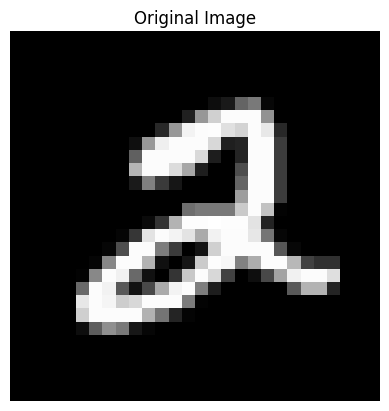

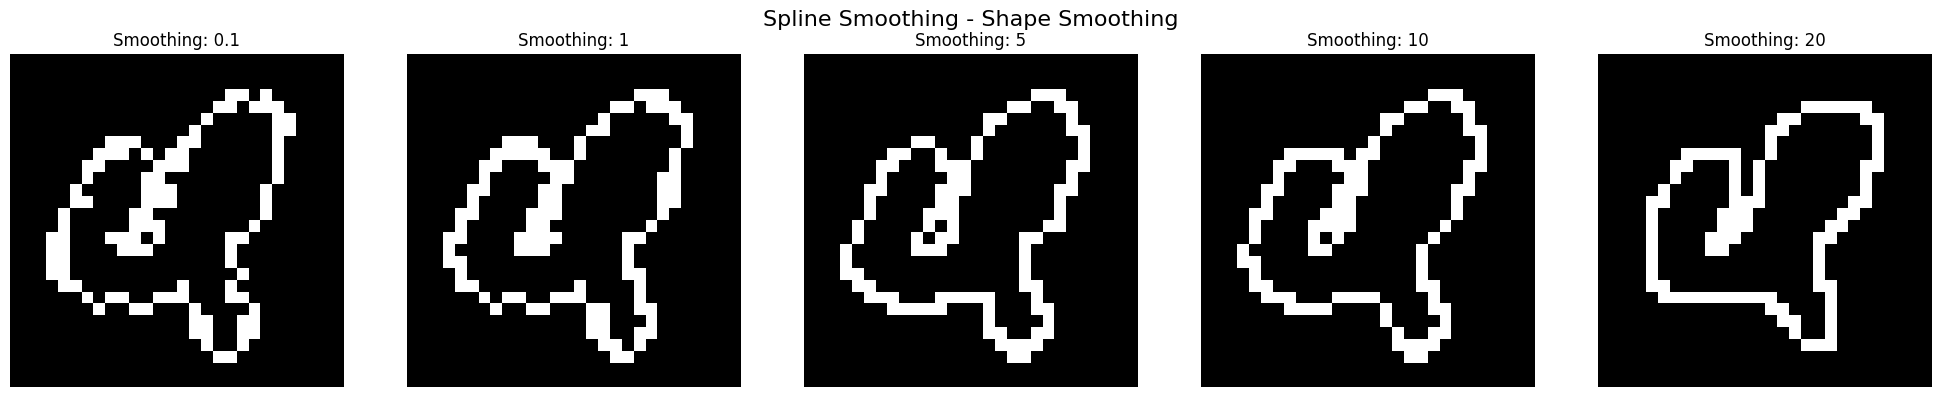

In [30]:
from skimage import measure
from scipy.interpolate import splprep, splev

smoothing_factors = [0.1, 1, 5, 10, 20]
blurred_images = []

contours = measure.find_contours(two_image, 0.5)
contour = contours[0]

for s in smoothing_factors:
    tck, _ = splprep([contour[:, 1], contour[:, 0]], s=s)
    u_new = np.linspace(0, 1, 300)
    x_new, y_new = splev(u_new, tck)

    smoothed_contour = np.stack((y_new, x_new), axis=1).astype(np.int32)

    canvas = np.zeros_like(two_image)
    cv2.polylines(canvas, [smoothed_contour], isClosed=True, color=255, thickness=1)

    blurred_images.append((s, canvas))

# Display the two_image
plt.imshow(two_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# Plotting all the results in a grid
plt.figure(figsize=(20, 4))  # Wide layout for easy comparison

for idx, (param, img) in enumerate(blurred_images):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Smoothing: {param}", fontsize=12)
    plt.axis('off')

plt.suptitle("Spline Smoothing - Shape Smoothing", fontsize=16)
plt.tight_layout()
plt.show()
